# 第 12 章 · AlphaFold 概念代码实验

[章节网页](../ch12.html)

## 运行内容

- 读取 MSA
- 计算位置保守性
- 绘制 pair 表征

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from PIL import Image
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits, load_iris, load_sample_image, make_moons
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import accuracy_score, confusion_matrix, log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.svm import SVC

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# AlphaFold 概念实验：用 insulin A-chain 风格 MSA 计算保守性和 pair 表征。
sequence = "GIVEQCCTSICSLYQLENYCN"
msa = [
    "GIVEQCCTSICSLYQLENYCN",
    "GIVEQCCASVCSLYQLENYCN",
    "GIVEQCCTSICSLYQLENFCN",
    "GLVEQCCTSICSLYQLENYCN",
    "GIVEQCCTSVCSLYQLENYCN",
]
msa_arr = np.array([list(row) for row in msa])
conservation = []
for col in msa_arr.T:
    counts = Counter(col)
    conservation.append(counts.most_common(1)[0][1] / len(col))
conservation = np.array(conservation)
pair_repr = np.outer(conservation, conservation)

pipeline_df = pd.DataFrame(
    [
        {"阶段": "MSA", "输出": f"{len(msa)} 条同源序列"},
        {"阶段": "保守性", "输出": "每个位置的最大频率"},
        {"阶段": "Pair 表征", "输出": f"{pair_repr.shape[0]}x{pair_repr.shape[1]} 矩阵"},
    ]
)
display(pipeline_df)
display(pd.DataFrame({"位置": range(1, len(sequence) + 1), "氨基酸": list(sequence), "保守性": conservation}).round(2))

,阶段,输出
0,MSA,5 条同源序列
1,保守性,每个位置的最大频率
2,Pair 表征,21x21 矩阵


,位置,氨基酸,保守性
0,1,G,1.0
1,2,I,0.8
2,3,V,1.0
3,4,E,1.0
4,5,Q,1.0
5,6,C,1.0
6,7,C,1.0
7,8,T,0.8
8,9,S,1.0
9,10,I,0.6


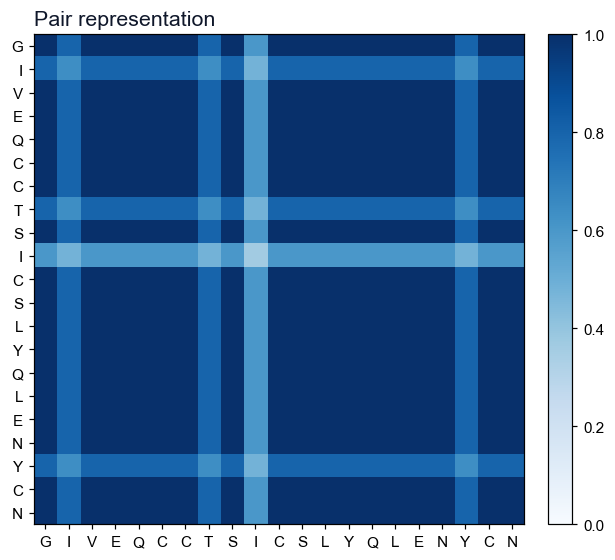

In [3]:
# 绘制 pair 表征热力图。
fig, ax = plt.subplots(figsize=(6.0, 5.2))
im = ax.imshow(pair_repr, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(sequence)), list(sequence))
ax.set_yticks(range(len(sequence)), list(sequence))
ax.set_title("Pair representation", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()